# Notebook chính của dự án
Chạy toàn bộ pipeline phát hiện xâm nhập mạng thời gian thực.

Dataset shape: (2522362, 71)


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,54865,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,55054,109,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,55055,52,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,46236,34,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,54863,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


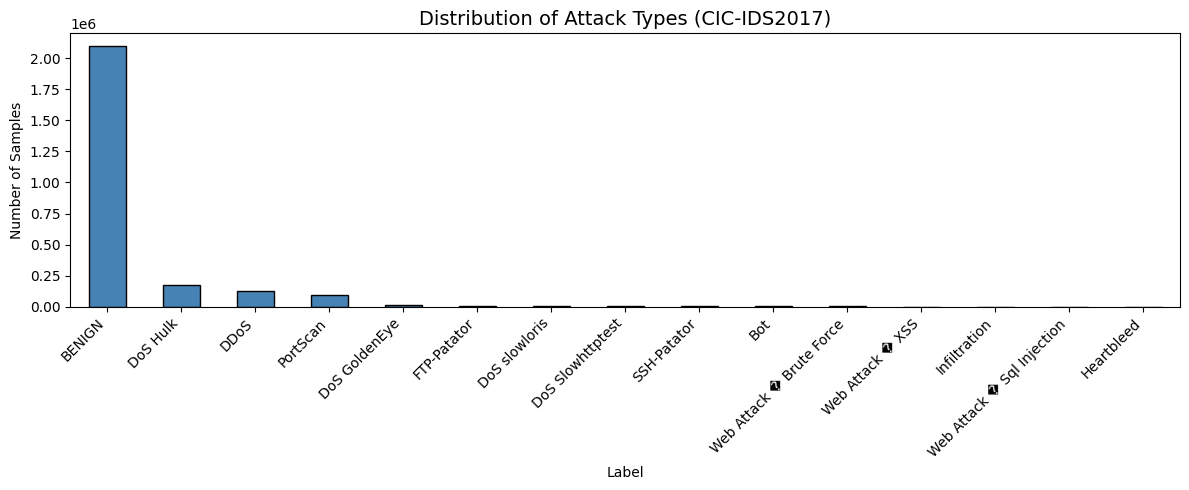


Class counts:
Label
BENIGN                        2096484
DoS Hulk                       172849
DDoS                           128016
PortScan                        90819
DoS GoldenEye                   10286
FTP-Patator                      5933
DoS slowloris                    5385
DoS Slowhttptest                 5228
SSH-Patator                      3219
Bot                              1953
Web Attack � Brute Force         1470
Web Attack � XSS                  652
Infiltration                       36
Web Attack � Sql Injection         21
Heartbleed                         11
Name: count, dtype: int64


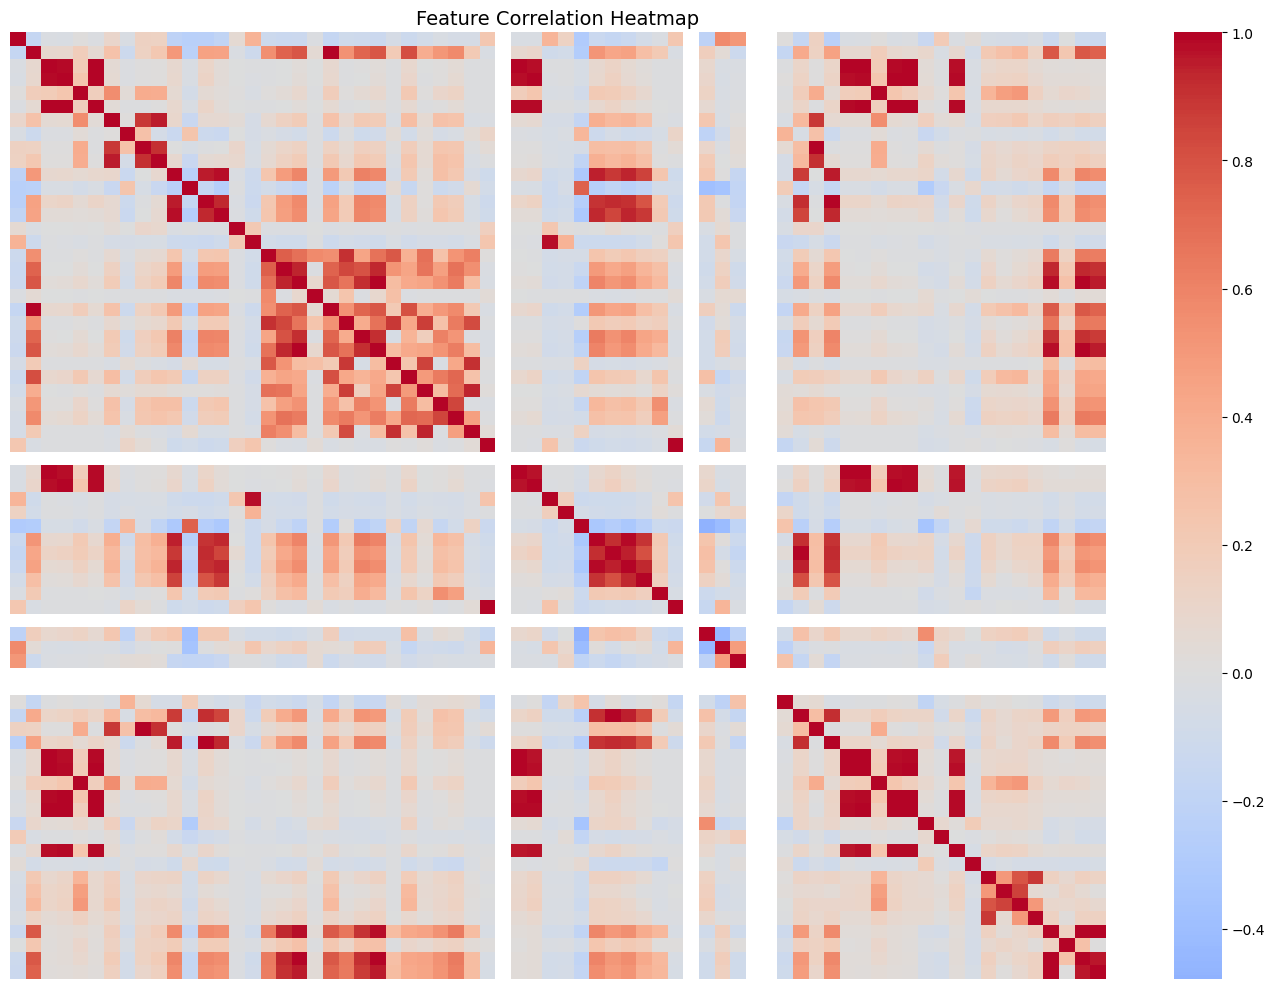


[Observation]
- Dataset is highly imbalanced: BENIGN dominates.
- Several features are highly correlated → feature selection needed.
- Class imbalance must be handled before model training (SMOTE + RUS).


In [1]:
# ==========================================
# 2.2 Exploratory Data Analysis & Data Preprocessing
# Thai Trung Quoc Hieu (TASK 2.2)
# Load cleaned data, EDA plots (attack distribution + correlation heatmap)
# ==========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os, gc

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
import joblib

# Load cleaned dataset (produced by scripts/eda_preprocessing.py)
df = pd.read_csv('../data/processed/cleaned_data.csv')
print(f'Dataset shape: {df.shape}')
display(df.head())

# --- Plot 1: Attack type distribution ---
plt.figure(figsize=(12, 5))
label_counts = df['Label'].value_counts()
label_counts.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Distribution of Attack Types (CIC-IDS2017)', fontsize=14)
plt.ylabel('Number of Samples')
plt.xlabel('Label')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()
print('\nClass counts:')
print(label_counts)

# --- Plot 2: Correlation Heatmap (sampled for performance) ---
sample_df = df.sample(5000, random_state=42)
corr = sample_df.select_dtypes(include='number').corr()

plt.figure(figsize=(14, 10))
sns.heatmap(corr, cmap='coolwarm', center=0, annot=False,
            xticklabels=False, yticklabels=False, linewidths=0)
plt.title('Feature Correlation Heatmap', fontsize=14)
plt.tight_layout()
plt.show()

# --- Observations ---
print('\n[Observation]')
print('- Dataset is highly imbalanced: BENIGN dominates.')
print('- Several features are highly correlated → feature selection needed.')
print('- Class imbalance must be handled before model training (SMOTE + RUS).')


In [2]:
# ==========================================
# 2.3 Handling Class Imbalance  +  2.4 Feature Selection
# Nguyen Gia Huy (TASK 2.3 & 2.4)
# - LabelEncode labels, scale features
# - Select 18 core features (per spec)
# - SMOTE (oversample minorities) then RandomUnderSampler (reduce BENIGN)
# - Save scaler & LabelEncoder for real-time inference
# ==========================================

# Reload cleaned data
df = pd.read_csv('../data/processed/cleaned_data.csv')

# Normalize column names (some CIC-IDS2017 files use long names)
column_mapping = {
    'Total Fwd Packets':           'Tot Fwd Pkts',
    'Total Backward Packets':      'Tot Bwd Pkts',
    'Total Length of Fwd Packets': 'TotLen Fwd Pkts',
    'Total Length of Bwd Packets': 'TotLen Bwd Pkts',
    'Fwd Packet Length Mean':      'Fwd Pkt Len Mean',
    'Bwd Packet Length Mean':      'Bwd Pkt Len Mean',
    'Flow Bytes/s':                'Flow Byts/s',
    'Flow Packets/s':              'Flow Pkts/s',
    'Packet Length Mean':          'Pkt Len Mean',
    'Packet Length Std':           'Pkt Len Std',
    'SYN Flag Count':              'SYN Flag Cnt',
    'ACK Flag Count':              'ACK Flag Cnt',
    'FIN Flag Count':              'FIN Flag Cnt',
    'RST Flag Count':              'RST Flag Cnt',
    'PSH Flag Count':              'PSH Flag Cnt',
    'URG Flag Count':              'URG Flag Cnt',
}
df.rename(columns=column_mapping, inplace=True)

# Encode Label
le = LabelEncoder()
df['Label'] = le.fit_transform(df['Label'])
print('Class encoding:', dict(enumerate(le.classes_)))

# Save LabelEncoder classes for real-time inference
os.makedirs('../models', exist_ok=True)
np.save('../models/label_classes.npy', le.classes_)
print('LabelEncoder classes saved to ../models/label_classes.npy')

# 18 core features as specified in the project requirements
selected_features = [
    'Protocol', 'Flow Duration', 'Tot Fwd Pkts', 'Tot Bwd Pkts',
    'TotLen Fwd Pkts', 'TotLen Bwd Pkts', 'Fwd Pkt Len Mean',
    'Bwd Pkt Len Mean', 'Flow Byts/s', 'Flow Pkts/s',
    'Pkt Len Mean', 'Pkt Len Std', 'SYN Flag Cnt',
    'ACK Flag Cnt', 'FIN Flag Cnt', 'RST Flag Cnt',
    'PSH Flag Cnt', 'URG Flag Cnt'
]
available_features = [f for f in selected_features if f in df.columns]
print(f'Using {len(available_features)}/18 features: {available_features}')

X = df[available_features].values
y = df['Label'].values
del df; gc.collect()

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
joblib.dump(scaler, '../models/scaler.pkl')
print('Scaler saved to ../models/scaler.pkl')

# Train / Test split BEFORE balancing to prevent data leakage
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)
print(f'\nTrain: {X_train.shape}  |  Test: {X_test.shape}')

unique, counts = np.unique(y_train, return_counts=True)
majority_class  = unique[np.argmax(counts)]
majority_count  = int(counts.max())
print('\nClass distribution BEFORE balancing:')
for cls, cnt in zip(unique, counts):
    print(f'  Class {cls} ({le.classes_[cls]}): {cnt}')

# --- Step 1: SMOTE – oversample minority classes to ~10% of majority ---
smote_target = max(int(majority_count * 0.1), 10)
smote_strategy = {
    int(cls): smote_target
    for cls, cnt in zip(unique, counts)
    if int(cnt) < majority_count and int(cnt) < smote_target
}
if smote_strategy:
    k_nn = min(3, int(min(counts[counts < majority_count])) - 1)
    k_nn = max(k_nn, 1)
    smote = SMOTE(sampling_strategy=smote_strategy, random_state=42, k_neighbors=k_nn)
    X_temp, y_temp = smote.fit_resample(X_train, y_train)
    print(f'\nAfter SMOTE: {X_temp.shape}')
else:
    X_temp, y_temp = X_train, y_train
    print('\nNo SMOTE needed (all classes already >= 10% of majority).')

# --- Step 2: RandomUnderSampler – reduce BENIGN to avoid majority bias ---
rus_target = min(100000, majority_count)
rus = RandomUnderSampler(
    sampling_strategy={majority_class: rus_target}, random_state=42
)
X_train, y_train = rus.fit_resample(X_temp, y_temp)
del X_temp, y_temp; gc.collect()

print('\nClass distribution AFTER balancing:')
u2, c2 = np.unique(y_train, return_counts=True)
for cls, cnt in zip(u2, c2):
    print(f'  Class {cls} ({le.classes_[cls]}): {cnt}')
print(f'Final balanced train set: {X_train.shape}')

# Save processed splits
os.makedirs('../data/processed', exist_ok=True)
np.save('../data/processed/X_train.npy', X_train)
np.save('../data/processed/y_train.npy', y_train)
np.save('../data/processed/X_test.npy',  X_test)
np.save('../data/processed/y_test.npy',  y_test)
print('\nSaved X_train, y_train, X_test, y_test to data/processed/')


Class encoding: {0: 'BENIGN', 1: 'Bot', 2: 'DDoS', 3: 'DoS GoldenEye', 4: 'DoS Hulk', 5: 'DoS Slowhttptest', 6: 'DoS slowloris', 7: 'FTP-Patator', 8: 'Heartbleed', 9: 'Infiltration', 10: 'PortScan', 11: 'SSH-Patator', 12: 'Web Attack � Brute Force', 13: 'Web Attack � Sql Injection', 14: 'Web Attack � XSS'}
LabelEncoder classes saved to ../models/label_classes.npy
Using 17/18 features: ['Flow Duration', 'Tot Fwd Pkts', 'Tot Bwd Pkts', 'TotLen Fwd Pkts', 'TotLen Bwd Pkts', 'Fwd Pkt Len Mean', 'Bwd Pkt Len Mean', 'Flow Byts/s', 'Flow Pkts/s', 'Pkt Len Mean', 'Pkt Len Std', 'SYN Flag Cnt', 'ACK Flag Cnt', 'FIN Flag Cnt', 'RST Flag Cnt', 'PSH Flag Cnt', 'URG Flag Cnt']
Scaler saved to ../models/scaler.pkl

Train: (2017889, 17)  |  Test: (504473, 17)

Class distribution BEFORE balancing:
  Class 0 (BENIGN): 1677187
  Class 1 (Bot): 1562
  Class 2 (DDoS): 102413
  Class 3 (DoS GoldenEye): 8229
  Class 4 (DoS Hulk): 138279
  Class 5 (DoS Slowhttptest): 4182
  Class 6 (DoS slowloris): 4308
  Cl

In [3]:
# ==========================================
# 2.5 Model Implementation & Comparison – helper function
# ==========================================
from sklearn.linear_model  import SGDClassifier
from sklearn.naive_bayes   import GaussianNB
from sklearn.neighbors     import KNeighborsClassifier
from sklearn.ensemble      import RandomForestClassifier
from sklearn.metrics       import classification_report, confusion_matrix, accuracy_score
from sklearn.metrics       import precision_score, recall_score, f1_score
import seaborn as sns
import joblib

def plot_results(y_true, y_pred, model_name):
    """Print classification report and plot confusion matrix."""
    print(f'\n=== RESULTS: {model_name.upper()} ===')
    print(classification_report(y_true, y_pred, target_names=le.classes_))
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 7))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=le.classes_, yticklabels=le.classes_)
    plt.title(f'Confusion Matrix – {model_name}', fontsize=13)
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()



Training Logistic Regression...

=== RESULTS: LOGISTIC REGRESSION ===
                            precision    recall  f1-score   support

                    BENIGN       1.00      0.48      0.65    419297
                       Bot       0.02      0.58      0.03       391
                      DDoS       0.38      0.89      0.53     25603
             DoS GoldenEye       0.10      0.66      0.18      2057
                  DoS Hulk       0.78      0.89      0.83     34570
          DoS Slowhttptest       0.03      0.78      0.05      1046
             DoS slowloris       0.11      0.55      0.18      1077
               FTP-Patator       0.03      0.31      0.06      1187
                Heartbleed       1.00      1.00      1.00         2
              Infiltration       0.00      0.86      0.00         7
                  PortScan       0.63      0.99      0.77     18164
               SSH-Patator       0.06      0.92      0.12       644
  Web Attack � Brute Force       0.01      0

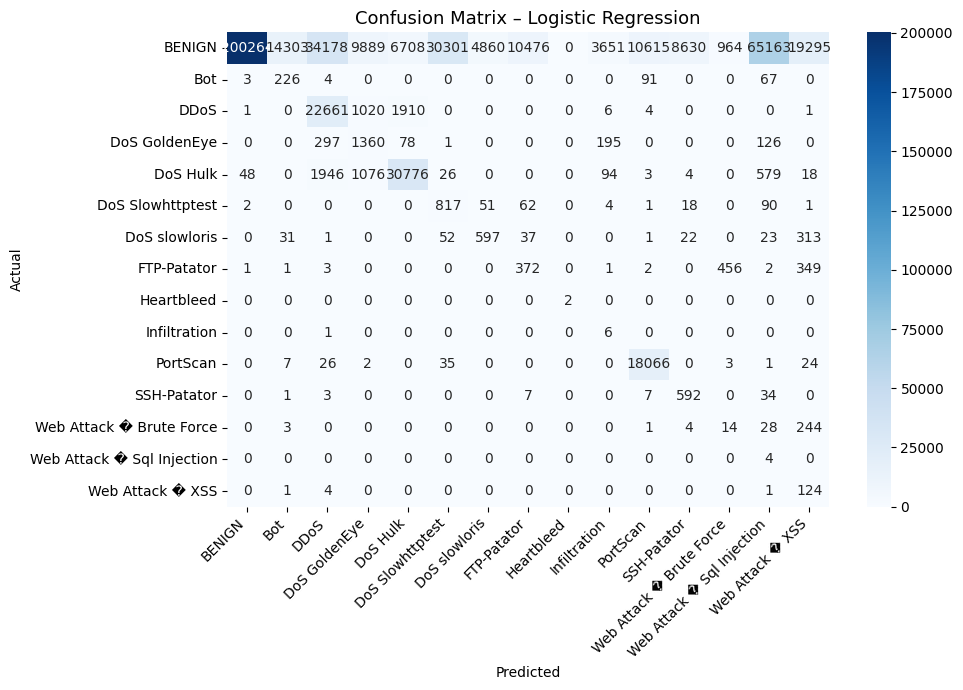

Model saved → ../models/logistic_regression.pkl

Training SVM (Linear)...

=== RESULTS: SVM (LINEAR) ===
                            precision    recall  f1-score   support

                    BENIGN       1.00      0.52      0.68    419297
                       Bot       0.01      0.48      0.03       391
                      DDoS       0.39      0.91      0.55     25603
             DoS GoldenEye       0.06      0.62      0.11      2057
                  DoS Hulk       0.79      0.87      0.83     34570
          DoS Slowhttptest       0.03      0.81      0.05      1046
             DoS slowloris       0.17      0.54      0.26      1077
               FTP-Patator       0.03      0.31      0.05      1187
                Heartbleed       0.67      1.00      0.80         2
              Infiltration       0.00      0.71      0.00         7
                  PortScan       0.60      0.99      0.75     18164
               SSH-Patator       0.11      0.92      0.20       644
  Web Atta

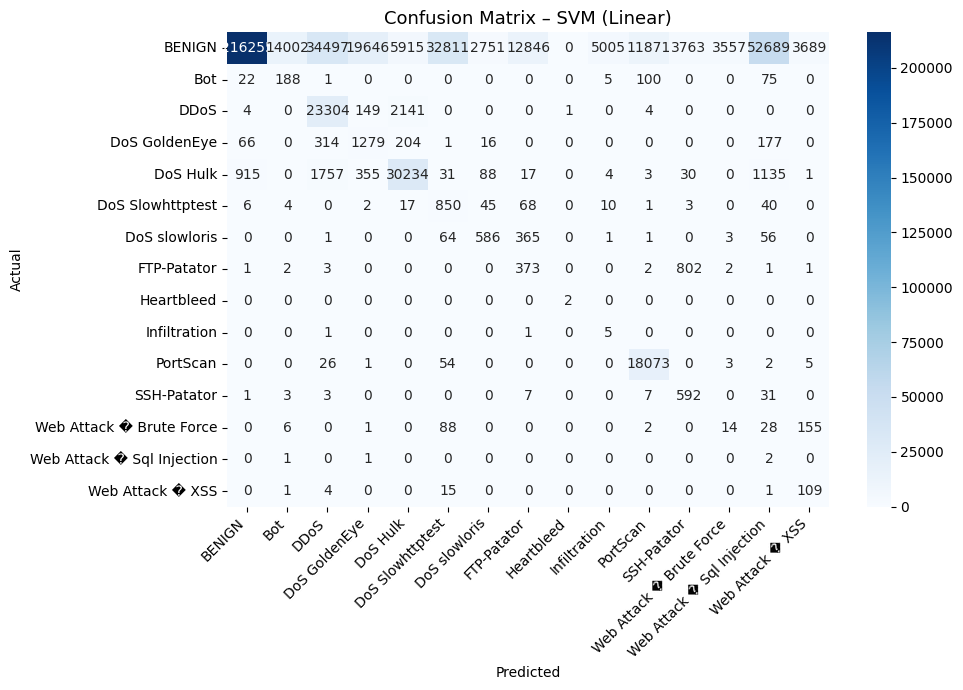

Model saved → ../models/svm_linear.pkl

Training Naive Bayes...

=== RESULTS: NAIVE BAYES ===
                            precision    recall  f1-score   support

                    BENIGN       1.00      0.07      0.12    419297
                       Bot       0.00      0.39      0.00       391
                      DDoS       0.83      0.25      0.38     25603
             DoS GoldenEye       0.02      0.96      0.04      2057
                  DoS Hulk       0.75      0.37      0.49     34570
          DoS Slowhttptest       0.00      0.08      0.01      1046
             DoS slowloris       0.03      0.57      0.06      1077
               FTP-Patator       0.14      0.99      0.24      1187
                Heartbleed       1.00      1.00      1.00         2
              Infiltration       0.01      0.86      0.01         7
                  PortScan       0.50      0.99      0.66     18164
               SSH-Patator       0.80      0.92      0.85       644
  Web Attack � Brute 

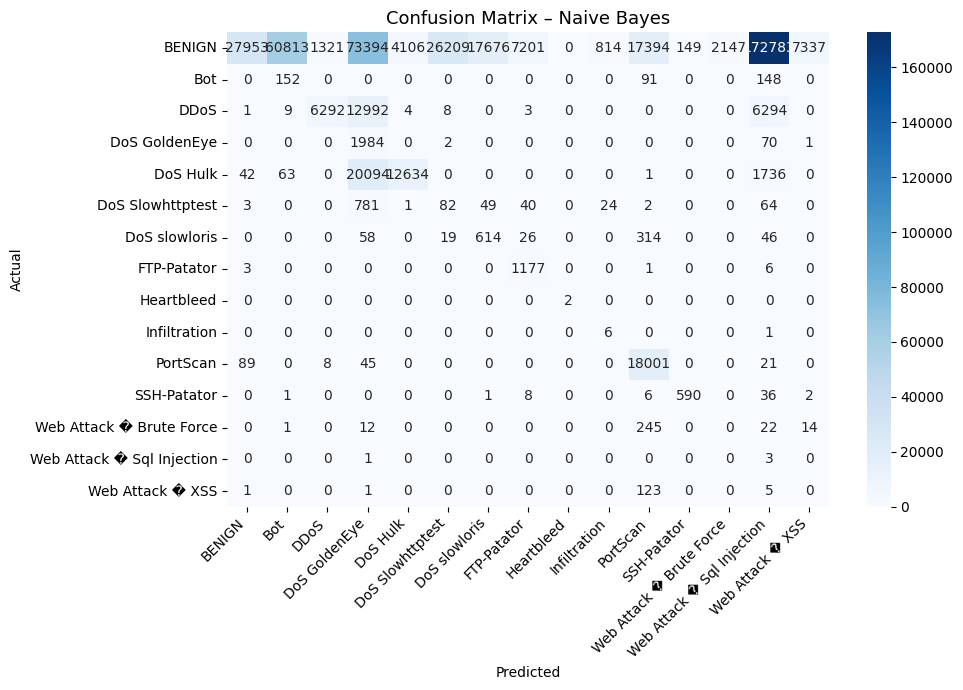

Model saved → ../models/naive_bayes.pkl

Training KNN...

=== RESULTS: KNN ===
                            precision    recall  f1-score   support

                    BENIGN       1.00      0.97      0.98    419297
                       Bot       0.17      0.63      0.27       391
                      DDoS       0.98      1.00      0.99     25603
             DoS GoldenEye       0.68      0.99      0.81      2057
                  DoS Hulk       0.95      0.99      0.97     34570
          DoS Slowhttptest       0.69      0.99      0.81      1046
             DoS slowloris       0.73      0.99      0.84      1077
               FTP-Patator       0.89      0.99      0.94      1187
                Heartbleed       1.00      1.00      1.00         2
              Infiltration       0.04      0.86      0.07         7
                  PortScan       0.97      0.98      0.98     18164
               SSH-Patator       0.37      0.95      0.53       644
  Web Attack � Brute Force       0.0

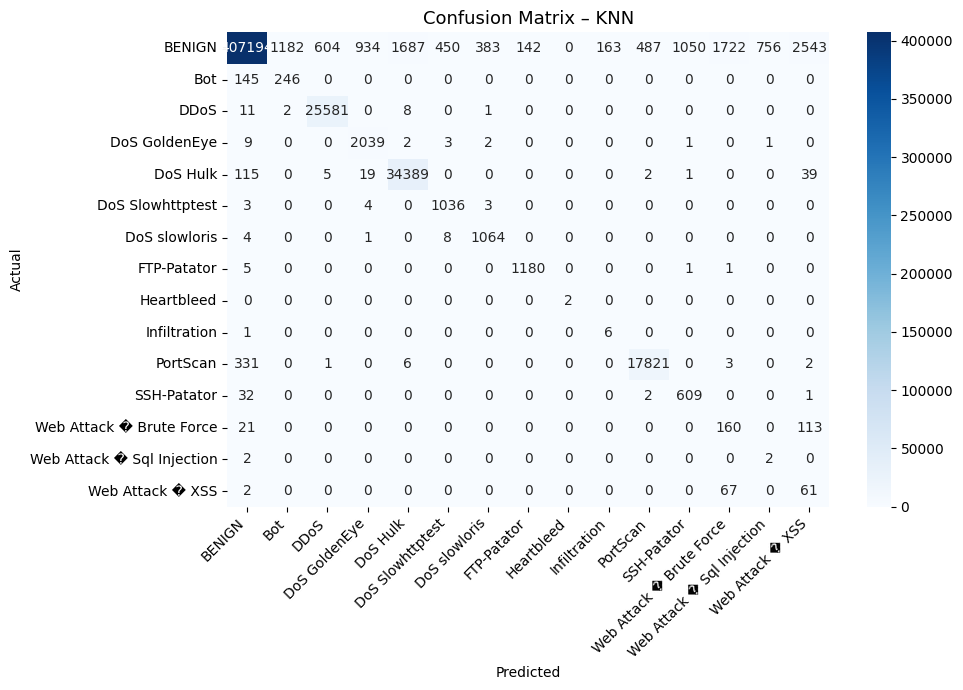

Model saved → ../models/knn.pkl

Training Random Forest...

=== RESULTS: RANDOM FOREST ===
                            precision    recall  f1-score   support

                    BENIGN       1.00      0.92      0.96    419297
                       Bot       0.03      1.00      0.06       391
                      DDoS       0.99      1.00      1.00     25603
             DoS GoldenEye       0.92      0.99      0.95      2057
                  DoS Hulk       0.97      1.00      0.98     34570
          DoS Slowhttptest       0.89      0.99      0.94      1046
             DoS slowloris       0.97      0.99      0.98      1077
               FTP-Patator       0.95      1.00      0.97      1187
                Heartbleed       0.67      1.00      0.80         2
              Infiltration       0.56      0.71      0.62         7
                  PortScan       0.99      1.00      0.99     18164
               SSH-Patator       0.22      0.95      0.36       644
  Web Attack � Brute For

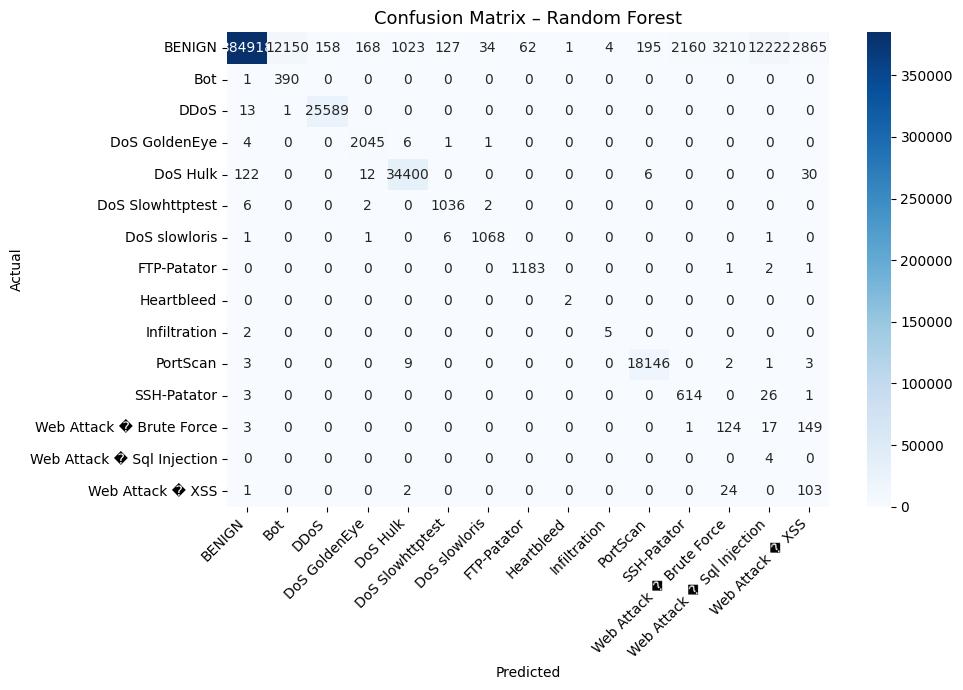

Model saved → ../models/random_forest.pkl

MODEL COMPARISON SUMMARY


,Accuracy,Precision,Recall,F1-score
Model,,,,
KNN,0.9741,0.9882,0.9741,0.9803
Random Forest,0.9309,0.9936,0.9309,0.9600
SVM (Linear),0.5786,0.9233,0.5786,0.6776
Logistic Regression,0.5469,0.9273,0.5469,0.6506
Naive Bayes,0.1377,0.9401,0.1377,0.1826



★ Best model: KNN  (F1=0.9803)
→ Random Forest will be used for real-time deployment (Section 2.6).


In [4]:
# ==========================================
# 2.5 Train all 5 models: LR, SVM, NB, KNN, Random Forest
# Evaluate each with classification_report + confusion matrix
# Produce a comparison table (Accuracy, Precision, Recall, F1)
# ==========================================

# Load balanced splits from disk (allows re-running this cell independently)
X_train_bal = np.load('../data/processed/X_train.npy')
y_train_bal = np.load('../data/processed/y_train.npy')
X_test_eval = np.load('../data/processed/X_test.npy')
y_test_eval = np.load('../data/processed/y_test.npy')

os.makedirs('../models', exist_ok=True)

models_def = {
    'Logistic Regression': SGDClassifier(
        loss='log_loss', n_jobs=-1, learning_rate='optimal',
        max_iter=1000, random_state=42
    ),
    'SVM (Linear)': SGDClassifier(
        loss='hinge', n_jobs=-1, learning_rate='optimal',
        max_iter=1000, random_state=42
    ),
    'Naive Bayes': GaussianNB(),
    'KNN': KNeighborsClassifier(n_neighbors=5, n_jobs=-1),
    'Random Forest': RandomForestClassifier(
        n_estimators=100, n_jobs=-1, random_state=42
    ),
}

comparison = []

for name, model in models_def.items():
    print(f'\nTraining {name}...')
    model.fit(X_train_bal, y_train_bal)
    y_pred = model.predict(X_test_eval)

    plot_results(y_test_eval, y_pred, name)

    # Save model
    fname = name.lower().replace(' ', '_').replace('(', '').replace(')', '').strip('_')
    joblib.dump(model, f'../models/{fname}.pkl')
    print(f'Model saved → ../models/{fname}.pkl')

    # Collect metrics for comparison table
    comparison.append({
        'Model':     name,
        'Accuracy':  round(accuracy_score(y_test_eval, y_pred), 4),
        'Precision': round(precision_score(y_test_eval, y_pred, average='weighted', zero_division=0), 4),
        'Recall':    round(recall_score(y_test_eval,    y_pred, average='weighted', zero_division=0), 4),
        'F1-score':  round(f1_score(y_test_eval,        y_pred, average='weighted', zero_division=0), 4),
    })

# --- Model comparison table ---
print('\n' + '='*60)
print('MODEL COMPARISON SUMMARY')
print('='*60)
cmp_df = pd.DataFrame(comparison).set_index('Model').sort_values('F1-score', ascending=False)
display(cmp_df)

best_model_name = cmp_df.index[0]
print(f'\n★ Best model: {best_model_name}  (F1={cmp_df.loc[best_model_name, "F1-score"]})')
print('→ Random Forest will be used for real-time deployment (Section 2.6).')


In [7]:
# ==========================================
# 2.6 Best Model Deployment – Real-time Alert Generation
# Duy Khai (TASK 2.6)
# Simulate receiving live network flows and generate Suricata-style alerts
# ==========================================
import time, random

# Load best model (Random Forest) and preprocessing artifacts
rf_model   = joblib.load('../models/random_forest.pkl')
scaler_rt  = joblib.load('../models/scaler.pkl')
le_classes = np.load('../models/label_classes.npy', allow_pickle=True)

SELECTED_FEATURES = [
    'Protocol', 'Flow Duration', 'Tot Fwd Pkts', 'Tot Bwd Pkts',
    'TotLen Fwd Pkts', 'TotLen Bwd Pkts', 'Fwd Pkt Len Mean',
    'Bwd Pkt Len Mean', 'Flow Byts/s', 'Flow Pkts/s',
    'Pkt Len Mean', 'Pkt Len Std', 'SYN Flag Cnt',
    'ACK Flag Cnt', 'FIN Flag Cnt', 'RST Flag Cnt',
    'PSH Flag Cnt', 'URG Flag Cnt'
]

def simulate_network_flow():
    """Simulate a single real-time network flow (random values for demo)."""
    # Use actual test samples occasionally to trigger real alerts
    if random.random() < 0.4:
        idx = random.randint(0, len(X_test_eval) - 1)
        return X_test_eval[idx].reshape(1, -1), int(y_test_eval[idx])
    else:
        raw = np.random.rand(len(SELECTED_FEATURES))
        scaled = scaler_rt.transform(raw.reshape(1, -1))
        return scaled, None  # unknown ground truth

def classify_flow(flow_scaled):
    """Classify a single pre-scaled network flow."""
    pred_idx = rf_model.predict(flow_scaled)[0]
    return le_classes[pred_idx]

log_path = '../alerts.log'
with open(log_path, 'w', encoding='utf-8') as f:
    f.write('')  # clear log

print('Starting real-time IDS simulation (15 flows)...')
print('-' * 60)

for i in range(15):
    flow, true_label = simulate_network_flow()
    label = classify_flow(flow)
    dest_port = random.choice([80, 443, 22, 21, 8080, 3389])

    if label != 'BENIGN':
        msg = f'[ALERT] Suspicious traffic detected: {label}. Destination Port: {dest_port}.'
        print(msg)
        with open(log_path, 'a', encoding='utf-8') as f:
            f.write(msg + '\n')
    else:
        print(f'[INFO]  Flow {i+1:02d}: BENIGN – no alert.')

print('-' * 60)
print(f'Simulation complete. Alerts written to {log_path}')


Starting real-time IDS simulation (15 flows)...
------------------------------------------------------------


ValueError: X has 18 features, but StandardScaler is expecting 17 features as input.